# VLM 모델 테스트

- 모델: Qwen2.5-VL-3B-Instruct
- 이미지: nedrug URL (앞면/뒷면이 한 장에 있으므로 **좌측 절반만 크롭**해서 사용)
- GT: pill_data.csv

In [40]:
import os
import json
import time
import requests
import torch
import pandas as pd
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

## 1. 매핑 테이블
GT는 한국어, 모델 출력은 영어이므로 비교를 위한 변환 테이블

In [ ]:
# 색상: 한국어 → 영어
COLOR_MAP = {
    "하양": "white",
    "노랑": "yellow",
    "주황": "orange",
    "분홍": "pink",
    "빨강": "red",
    "갈색": "brown",
    "연두": "light green",
    "초록": "green",
    "청록": "teal",
    "파랑": "blue",
    "남색": "navy",
    "자주": "purple",
    "보라": "violet",
    "회색": "gray",
    "검정": "black",
    "투명": "transparent",
}

# 형태: 한국어 → 영어
SHAPE_MAP = {
    "원형":      "round",
    "타원형":    "oval",
    "장방형":    "oblong",
    "반원형":    "semicircle",
    "삼각형":    "triangle",
    "사각형":    "rectangle",
    "마름모형":  "diamond",
    "오각형":    "pentagon",
    "육각형":    "hexagon",
    "팔각형":    "octagon",
    "기타":      "other",
    "8자형":     "figure-8",
    "강낭콩형":  "kidney",
    "과일모양":  "fruit",
    "구형":      "sphere",
    "나비넥타이형": "bowtie",
    "나비모양":  "butterfly",
    "다이아몬드형": "diamond",
    "도넛형":    "donut",
    "캡슐형":    "capsule",
}

def translate_color(kor: str) -> str:
    """복합 색상 처리 (e.g. '파랑|투명' → 'blue') — 첫 번째 색상 기준"""
    if not kor or kor == "-":
        return ""
    primary = kor.split("|")[0].strip()
    return COLOR_MAP.get(primary, primary)

def translate_shape(kor: str) -> str:
    if not kor or kor == "-":
        return ""
    return SHAPE_MAP.get(kor.strip(), kor.strip())

print("매핑 테이블 로드 완료")
print(f"  색상 {len(COLOR_MAP)}종 / 형태 {len(SHAPE_MAP)}종")

매핑 테이블 로드 완료
  색상 16종 / 형태 20종


## 2. 모델 로드

In [42]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map=None,
    ignore_mismatched_sizes=True
).to("mps")

processor = AutoProcessor.from_pretrained(model_id)
print("모델 로드 완료:", model_id)

Loading weights: 100%|██████████| 824/824 [00:10<00:00, 80.34it/s] 


모델 로드 완료: Qwen/Qwen2.5-VL-3B-Instruct


## 3. 유틸 함수

In [51]:
def fetch_image(url: str) -> Image.Image | None:
    """URL에서 이미지 다운로드"""
    if not url or str(url).strip() in ("", "-", "nan"):
        return None
    try:
        res = requests.get(url.strip(), timeout=10)
        if res.status_code != 200:
            return None
        return Image.open(BytesIO(res.content)).convert("RGB")
    except Exception as e:
        print(f"  다운로드 실패 ({url}): {e}")
        return None


def crop_front(image: Image.Image) -> Image.Image:
    """
    한 장 이미지에서 앞면(좌측 절반)만 크롭.
    nedrug 이미지는 앞면(좌) + 뒷면(우)으로 구성됨.
    """
    w, h = image.size
    return image.crop((0, 0, w // 2, h))


def identify_pill(image: Image.Image) -> dict:
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": (
                "Look at this pill image carefully.\n"
                "Return ONLY a JSON object with these exact keys:\n"
                "- color: pill color in English (e.g. white, orange, yellow, pink, green, blue)\n"
                "- shape: one of [round, oval, oblong, capsule, triangle, rectangle, diamond, pentagon, hexagon, octagon, other]\n"
                "- print: ALL text imprinted on this pill, concatenated with space (empty string if none)\n"
                "No explanation. Output JSON only."
            )}
        ]
    }]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text], images=[image], return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=200, do_sample=False)

    result = processor.decode(output[0], skip_special_tokens=True)
    start = result.find("{")
    end = result.rfind("}") + 1
    if start == -1 or end == 0:
        return {"parse_error": True, "raw": result}
    try:
        return json.loads(result[start:end])
    except json.JSONDecodeError:
        return {"parse_error": True, "raw": result}


print("함수 선언 완료")

함수 선언 완료


## 4. 단일 이미지 제로샷 테스트

예측 결과: {'color': 'white', 'shape': 'round', 'print': 'ASPIRIN 0.5'}


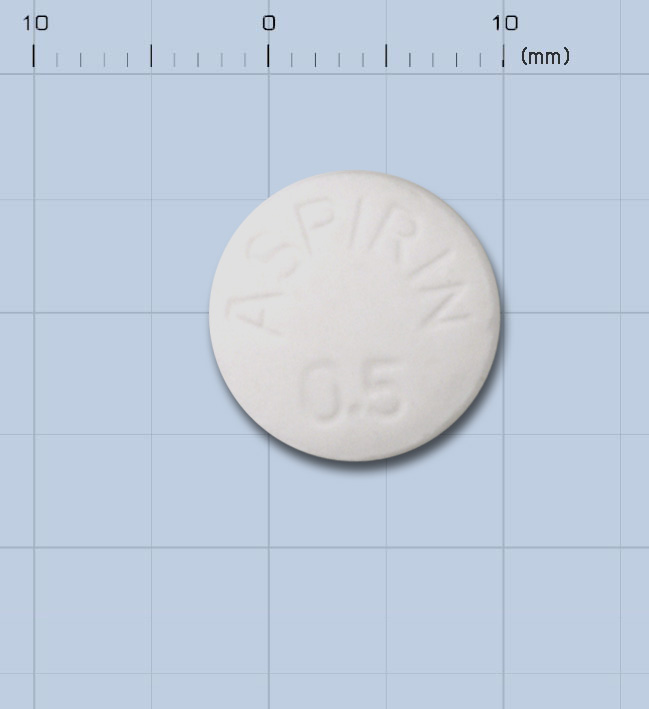

In [52]:
# 로컬 이미지로 테스트
test_image_path = "/Users/hsj/Documents/GitHub/alyak-deep-learning-app/deep_learning_prj/data/A11ABBBBB133801.jpg"

img = Image.open(test_image_path).convert("RGB")
front = crop_front(img)   # 좌측 앞면만 크롭

result = identify_pill(front)
print("예측 결과:", result)

# 크롭 확인용
front  # 노트북에서 이미지 미리보기

## 5. 벤치마크 (CSV 기반, 제로샷)

In [53]:
# ── 설정 ──────────────────────────────────────────
CSV_PATH   = "pill_data.csv"
SAMPLE_N   = 100          # None 이면 전체
OUTPUT_CSV = "benchmark_results.csv"
REQUEST_DELAY = 0.2

# ── CSV 로드 ───────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, encoding="utf-8-sig", low_memory=False)
print(f"전체: {len(df_raw)}개")

# 이미지 URL 있는 행만
df_raw = df_raw[df_raw["큰제품이미지"].notna()].copy()
df_raw = df_raw[df_raw["큰제품이미지"].str.startswith("http", na=False)].copy()
print(f"이미지 URL 있는 데이터: {len(df_raw)}개")

# ── GT print 전처리 함수 (앞면 전용) ───────────────────
def build_gt_print_front(front: str) -> str:
    """
    표시앞만 GT print로 사용.
    - '-' 는 빈값으로 처리
    - '분할선', 'V분할선X' 패턴은 제거 (인쇄문자 아님)
    """
    import re

    val = str(front).strip()
    if val in ("-", "nan", ""):
        return ""

    # 분할선 패턴 제거: '분할선', 'V분할선T', '분할선있음' 등
    val = re.sub(r"V?분할선\w*", "", val).strip()
    return val

# ── 샘플링 ─────────────────────────────────────────
if SAMPLE_N:
    df_sample = df_raw.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)
else:
    df_sample = df_raw.reset_index(drop=True)

print(f"샘플링: {len(df_sample)}개")

# GT print(앞면) 미리보기
df_sample["gt_print_front"] = df_sample["표시앞"].apply(build_gt_print_front)
df_sample[["품목명", "색상앞", "의약품제형", "표시앞", "gt_print_front"]].head(5)

전체: 27616개
이미지 URL 있는 데이터: 27616개
샘플링: 100개


,품목명,색상앞,의약품제형,표시앞,gt_print_front
0,크로바틴정20mg(로수바스타틴칼슘),분홍,원형,BP,BP
1,이센트레스에이치디정(랄테그라비르칼륨(미분화)),노랑,타원형,마크242,마크242
2,제큐스연질캡슐(수출명:Bee-marinsoftcapsule|Beemari-Bsoft...,갈색,장방형,제큐스,제큐스
3,대웅바이오프로피베린정20밀리그램(프로피베린염산염),하양,원형,PV,PV
4,휴텍스라니티딘정75mg(라니티딘염산염),분홍,원형,H75,H75


In [57]:
def normalize(text: str) -> str:
    return str(text).strip().lower().replace(" ", "").replace("-", "")

def is_print_match(pred: str, gt: str) -> bool:
    """GT가 '-' 이면 빈 문자열로 처리"""
    gt_clean = "" if str(gt).strip() in ("-", "nan", "") else str(gt).strip()
    return normalize(pred) == normalize(gt_clean)


records = []

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    url = str(row.get("큰제품이미지", "")).strip()

    # GT (한국어 → 영어 변환)
    gt_color_kor = str(row.get("색상앞", "")).strip()
    gt_shape_kor = str(row.get("의약품제형", "")).strip()
    gt_print_front = build_gt_print_front(row.get("표시앞", ""))

    gt_color_en = translate_color(gt_color_kor)
    gt_shape_en = translate_shape(gt_shape_kor)

    # 이미지 다운로드 → 앞면 크롭
    full_img = fetch_image(url)
    if full_img is None:
        continue
    front_img = crop_front(full_img)

    # 추론
    pred = identify_pill(front_img)
    parse_error = pred.get("parse_error", False)
    pred_print = pred.get("print", "")

    # 정확도 평가 (앞면 인쇄만 사용)
    correct_color = normalize(pred.get("color", "")) == normalize(gt_color_en)
    correct_shape = normalize(pred.get("shape", "")) == normalize(gt_shape_en)
    correct_print_front = is_print_match(pred_print, gt_print_front)

    records.append({
        "품목명":            row.get("품목명", ""),
        "품목일련번호":      row.get("품목일련번호", ""),
        "gt_color_kor":     gt_color_kor,
        "gt_color_en":      gt_color_en,
        "gt_shape_kor":     gt_shape_kor,
        "gt_shape_en":      gt_shape_en,
        "gt_print_front":   gt_print_front,
        "pred_color":       pred.get("color", ""),
        "pred_shape":       pred.get("shape", ""),
        "pred_print_front": pred_print,
        "correct_color":        correct_color,
        "correct_shape":        correct_shape,
        "correct_print_front":  correct_print_front,
        "all_correct":  all([correct_color, correct_shape, correct_print_front]),
        "parse_error":  parse_error,
        "image_url":    url,
    })

    time.sleep(REQUEST_DELAY)


result_df = pd.DataFrame(records)
result_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n결과 저장 → {OUTPUT_CSV}")

100%|██████████| 100/100 [05:32<00:00,  3.32s/it]


결과 저장 → benchmark_results.csv


## 6. 결과 분석

In [58]:
total = len(result_df)
print(f"{'='*45}")
print(f" 총 평가 샘플: {total}개  /  파싱 오류: {result_df['parse_error'].sum()}개")
print(f"{'='*45}")
for key, label in [
    ("correct_color",       "색상     "),
    ("correct_shape",       "형태     "),
    ("correct_print_front", "인쇄(앞) "),
    ("all_correct",         "전체 일치"),
]:
    acc = result_df[key].mean() * 100
    n   = result_df[key].sum()
    print(f"  {label}: {acc:5.1f}%  ({int(n)}/{total})")
print(f"{'='*45}")

 총 평가 샘플: 100개  /  파싱 오류: 0개
  색상     :  66.0%  (66/100)
  형태     :  72.0%  (72/100)
  인쇄(앞) :  65.0%  (65/100)
  전체 일치:  29.0%  (29/100)


In [59]:
# 색상 오류 패턴
print("[ 색상 오류 패턴 (상위 10) ]")
wrong_color = result_df[~result_df["correct_color"]]
print(
    wrong_color
    .groupby(["gt_color_kor", "gt_color_en", "pred_color"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

print("\n[ 형태 오류 패턴 (상위 10) ]")
wrong_shape = result_df[~result_df["correct_shape"]]
print(
    wrong_shape
    .groupby(["gt_shape_kor", "gt_shape_en", "pred_shape"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

print("\n[ 인쇄문자(앞) 오류 샘플 (상위 20) ]")
wrong_print = result_df[~result_df["correct_print_front"]]
print(
    wrong_print[["품목명", "gt_print_front", "pred_print_front"]]
    .head(20)
    .to_string(index=False)
)

[ 색상 오류 패턴 (상위 10) ]
gt_color_kor  gt_color_en  pred_color
연두            light green  green         7
분홍            pink         orange        6
주황            orange       yellow        5
갈색            brown        orange        2
분홍            pink         beige         2
파랑            blue         white         2
갈색            brown        red           1
                           tan           1
                           yellow        1
갈색|투명         brown        orange        1

[ 형태 오류 패턴 (상위 10) ]
gt_shape_kor  gt_shape_en  pred_shape
장방형           oblong       oval          16
                           capsule        8
원형            round        oval           3
기타            other        oval           1

[ 인쇄문자(앞) 오류 샘플 (상위 20) ]
                        품목명 gt_print_front pred_print_front
  이센트레스에이치디정(랄테그라비르칼륨(미분화))          마크242              242
         조피스타정1밀리그램(에스조피클론)            EZ1             EZ I
            텔미일정40mg(텔미사르탄)              T              TL1
        

## 7. 파인튜닝 